# Statistical Time Series Forecasting — Notebook 2
## Time Series Decomposition

**Goal:** Split a series into interpretable components — trend, seasonality, and residual — and learn when to use *additive* vs *multiplicative* models.

---

### Why decompose?

Decomposition is **diagnostic**, not directly predictive:

1. It exposes structure — is the series mostly trend? Mostly seasonality?
2. It checks model assumptions — are residuals close to white noise?
3. It feeds downstream choices — should we difference? Take a log? Use Holt-Winters?

### The two classical models

**Additive:**  
$$y_t = T_t + S_t + R_t$$  
Use when the *amplitude* of seasonal fluctuations is roughly constant over time.

**Multiplicative:**  
$$y_t = T_t \times S_t \times R_t$$  
Use when the seasonal swings *grow with the level* of the series. Equivalent to additive on the log of the series.

### Two algorithms we'll use

- **Classical (`seasonal_decompose`)** — moving-average based, simple, fast. Edges of the series have NaNs.
- **STL (Seasonal-Trend decomposition using Loess)** — handles changing seasonality, robust to outliers, no edge NaNs. Generally preferred.


## Setup

Run this once per Colab session.

1. Upload `tsf_utils.py` to your Colab runtime (left sidebar → **Files** → upload), **or** mount Google Drive and add the folder to `sys.path`.
2. Place your dataset CSV/Excel file in the same location.
3. Run the cells below.


In [2]:
# Standard imports used throughout the tutorial
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots

# In Colab, the notebook renderer is auto-detected. If plots don't show,
# uncomment the next line:
# pio.renderers.default = "colab"

pio.templates.default = "plotly_white"

# Our reusable utilities (returns plotly Figures)
import tsf_utils as tsf
print("tsf_utils loaded — sample functions:",
      [f for f in dir(tsf) if f.startswith('plot_')][:6], '...')


tsf_utils loaded — sample functions: ['plot_acf_pacf', 'plot_compare_pair', 'plot_distribution', 'plot_forecast', 'plot_intermittent_series', 'plot_lag'] ...


In [3]:
# ----------------------------------------------------------
# LOAD YOUR DATASET — edit these four lines for your data
# ----------------------------------------------------------

df = sns.load_dataset("flights")  # columns: year, month, passengers
df["Date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")
series = df.set_index("Date")["passengers"].asfreq("MS").rename("passengers")

DATE_COL = 'Date'
VALUE_COL = 'passengers'
FREQ = 'MS'

#DATA_PATH   = "your_dataset.csv"   # path to CSV or .xlsx
#DATE_COL    = "Date"               # column with timestamps
#VALUE_COL   = "Sales"              # column to forecast (univariate)
#FREQ        = "MS"                 # 'D','W','MS','M','Q','A','H' or None

#series = tsf.load_timeseries(
#    path=DATA_PATH,
#    date_col=DATE_COL,
#    value_col=VALUE_COL,
#    freq=FREQ,
#    fill_method="interpolate",
#)

print("Length:", len(series))
print("Frequency:", series.index.freqstr)
print("Range:", series.index.min(), "→", series.index.max())
series.head()


Length: 144
Frequency: MS
Range: 1949-01-01 00:00:00 → 1960-12-01 00:00:00


Date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: passengers, dtype: int64

## 1. Decide additive vs multiplicative — visually

Plot the series. If the seasonal swings *grow over time*, go multiplicative.

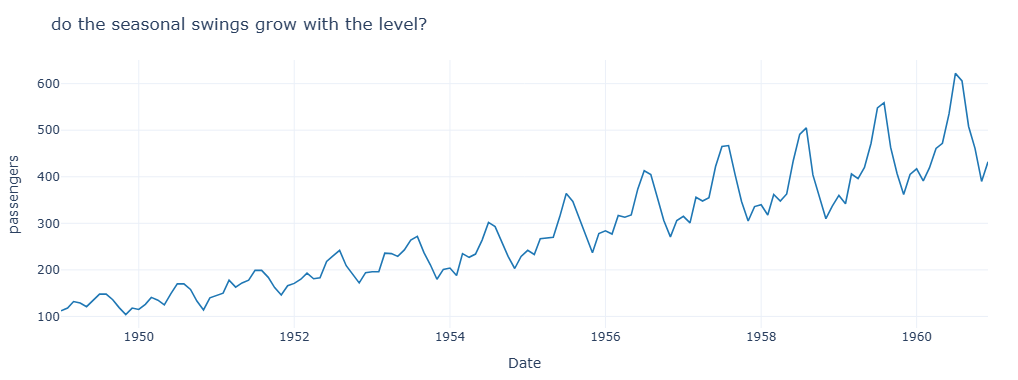

In [5]:
tsf.plot_timeseries(series, title="do the seasonal swings grow with the level?").show()

## 2. Classical decomposition (additive)

`decompose_and_plot` returns both the statsmodels result object and the plotly figure.

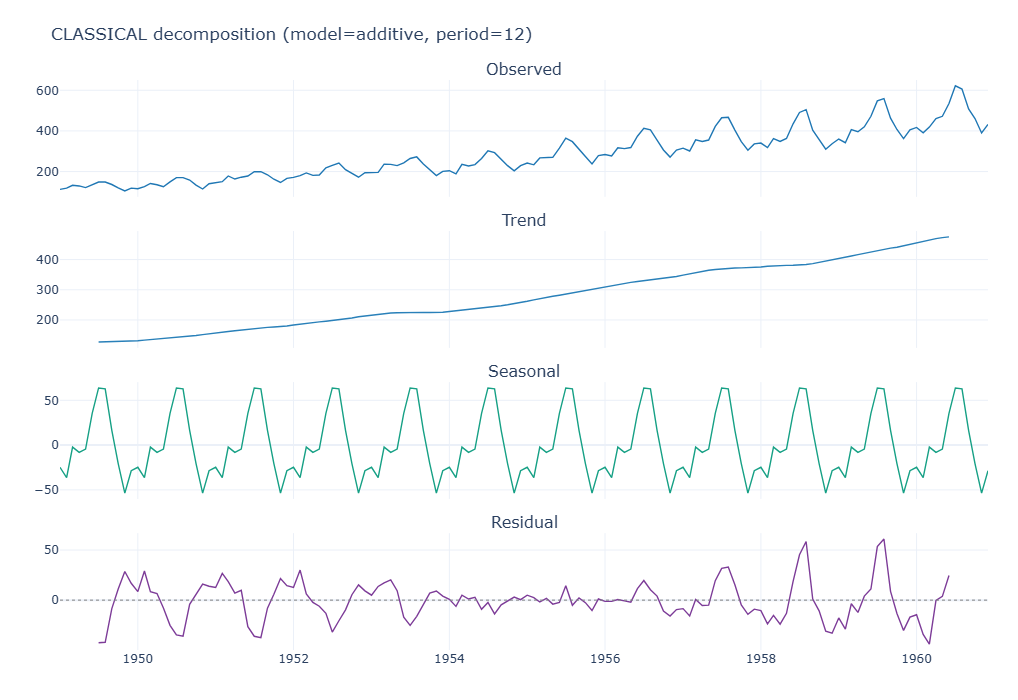

In [6]:
result_add, fig_add = tsf.decompose_and_plot(series, model="additive", method="classical")
fig_add.show()

## 3. Classical decomposition (multiplicative)

>  Multiplicative requires **all-positive** values. If your series has zeros or negatives, stick to additive (or shift the series).

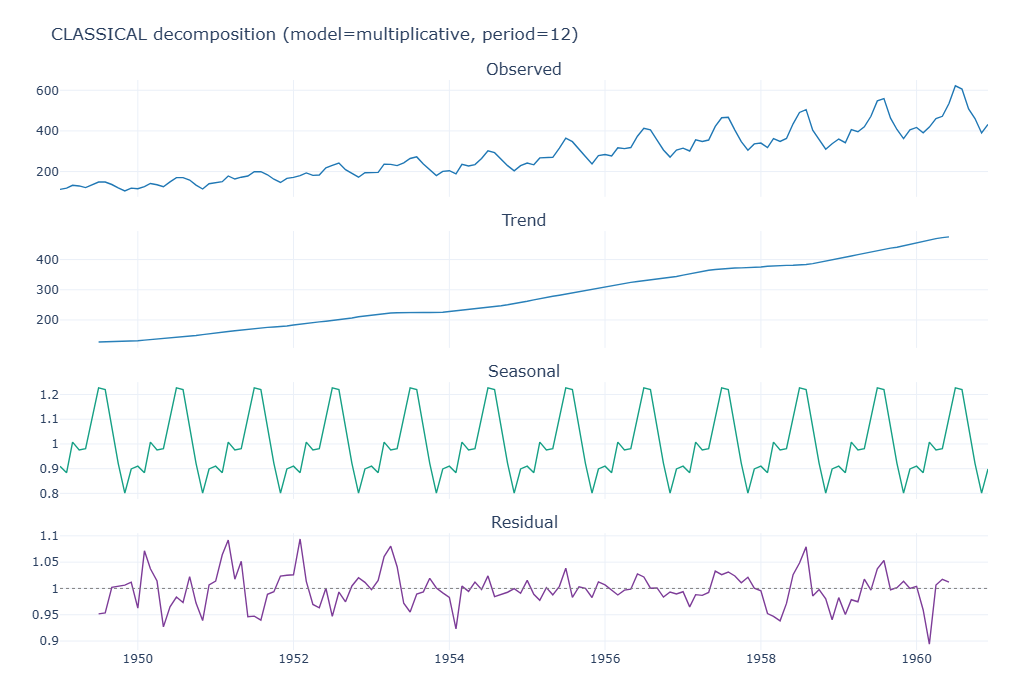

In [7]:
if (series.dropna() > 0).all():
    result_mul, fig_mul = tsf.decompose_and_plot(series, model="multiplicative", method="classical")
    fig_mul.show()
else:
    print("Series contains zero or negative values — multiplicative model not applicable.")

## 4. STL decomposition (preferred for most real data)

STL is more robust and lets seasonality evolve gently over time.

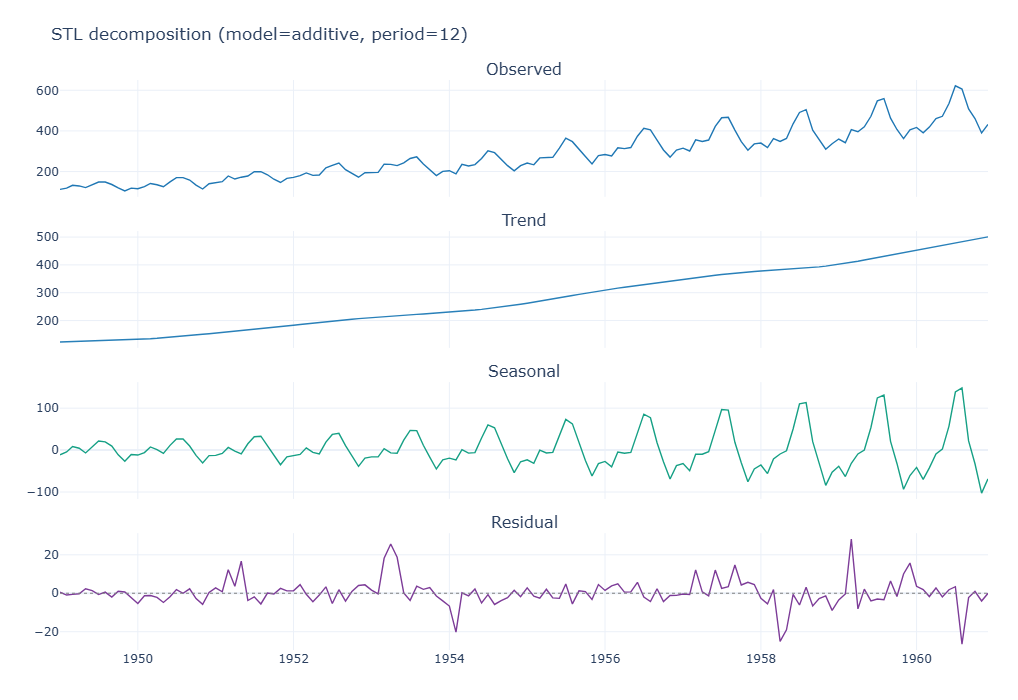

In [8]:
result_stl, fig_stl = tsf.decompose_and_plot(series, method="stl")
fig_stl.show()

## 5. Reading the components

- **Trend panel** — should look smooth. Sudden jumps suggest a structural break.
- **Seasonal panel** — same shape repeated every cycle. Amplitude may grow (multiplicative case).
- **Residual panel** — should hover around zero (additive) or one (multiplicative) with no obvious pattern. If you still see structure here, the decomposition has missed something.

## 6. Quantifying strength of trend & seasonality

A handy summary from Hyndman & Athanasopoulos:
$$F_T = \max\!\left(0,\; 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(T_t + R_t)}\right),\quad
  F_S = \max\!\left(0,\; 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(S_t + R_t)}\right)$$
Both lie in [0, 1]. Closer to 1 means the corresponding component dominates.

In [9]:
def strength(component, residual):
    detrended = component + residual
    var_resid = np.nanvar(residual)
    var_total = np.nanvar(detrended)
    return max(0.0, 1.0 - var_resid / var_total) if var_total > 0 else 0.0

trend_strength    = strength(result_stl.trend.dropna(),    result_stl.resid.dropna())
seasonal_strength = strength(result_stl.seasonal.dropna(), result_stl.resid.dropna())

print(f"Trend strength    F_T = {trend_strength:.3f}")
print(f"Seasonal strength F_S = {seasonal_strength:.3f}")

Trend strength    F_T = 0.996
Seasonal strength F_S = 0.975


## 7. Seasonally-adjusted series

Subtracting the seasonal component gives you a *seasonally adjusted* view — useful for spotting underlying trend changes. Toggle the legend to compare.

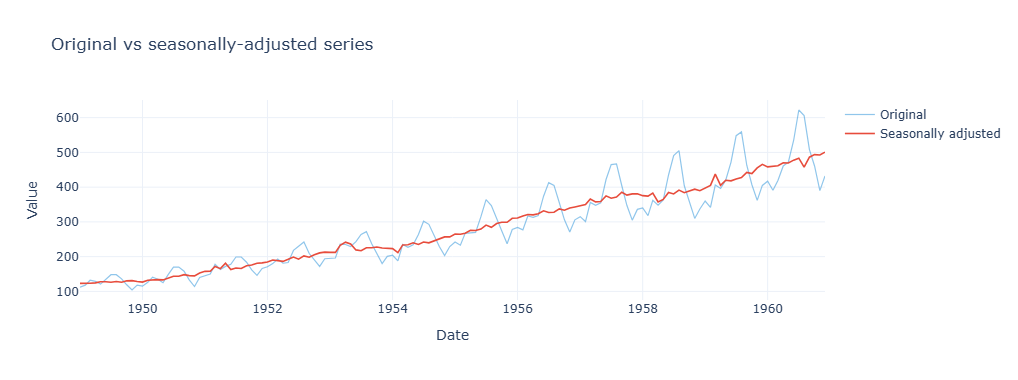

In [10]:
seasonally_adjusted = series - result_stl.seasonal

fig = go.Figure()
fig.add_trace(go.Scatter(x=series.index, y=series.values, mode="lines",
                         name="Original", opacity=0.55,
                         line=dict(color="#3498db", width=1.2)))
fig.add_trace(go.Scatter(x=seasonally_adjusted.index, y=seasonally_adjusted.values,
                         mode="lines", name="Seasonally adjusted",
                         line=dict(color="#e74c3c", width=1.6)))
fig.update_layout(title="Original vs seasonally-adjusted series",
                  xaxis_title="Date", yaxis_title="Value", height=380,
                  hovermode="x unified")
fig.show()

## Takeaways

- **Additive** when seasonal amplitude is constant; **multiplicative** when it scales with the level.
- **STL** is more robust than classical decomposition and should be your default.
- **Residuals from a good decomposition look like noise** — if they don't, the model is missing something.
- **Strength scores `F_T`, `F_S`** quickly tell you whether trend or seasonality dominates.

Next: **Notebook 3 — Stationarity & Statistical Tests**.
